# Análise da Tabela 3 — Áreas gerais de formação na graduação

**Objetivo:** dividir a Tabela 3 em três conjuntos por Grande Região e sexo, salvar as tabelas em Excel e apresentar as estatísticas descritivas com `describe()`.

As três tabelas analisadas são:
1. Pessoas com nível superior completo — Homens e Mulheres por região.
2. Pessoas com formação nas áreas de Ciência, Tecnologia, Engenharias e Matemática — Homens e Mulheres por região.
3. Pessoas com formação nas áreas de Educação, Serviços pessoais, Saúde e Bem-estar — Homens e Mulheres por região.

> As linhas utilizadas são as cinco Grandes Regiões: Norte, Nordeste, Sudeste, Sul e Centro-Oeste. A linha Brasil e as Unidades da Federação não entram nas três tabelas regionais.

In [1]:
from pathlib import Path

PASTA_PROJETO = Path.cwd()
path = PASTA_PROJETO / "Tabela_3_Areas_gerais_de_formacao_na_graduacao.xlsx"

print("Arquivo da atividade:", path)

Arquivo da atividade: /mnt/data/GitNovo_work/AtividadeAnalisarTabela/Tabela_3_Areas_gerais_de_formacao_na_graduacao.xlsx


In [2]:
import pandas as pd

# Leitura da Tabela 3. A terceira linha contém os nomes das colunas.
dados = pd.read_excel(path, header=2)
dados = dados.rename(columns={"Unnamed: 0": "Região/UF"})

dados.head()


,Região/UF,Total,Homens,Mulheres,Total.1,Homens.1,Mulheres.1,Total.2,Homens.2,Mulheres.2
0,Brasil,25854291.0,10478534.0,15375757.0,4149041.0,2750422.0,1398619.0,8079707.0,1677985.0,6401723.0
1,Norte,1525166.0,590558.0,934609.0,209657.0,133055.0,76601.0,599785.0,141169.0,458616.0
2,Nordeste,4748933.0,1744994.0,3003939.0,621388.0,389993.0,231395.0,1822087.0,363905.0,1458181.0
3,Sudeste,12828829.0,5391638.0,7437191.0,2328122.0,1588874.0,739247.0,3652397.0,768288.0,2884108.0
4,Sul,4338861.0,1768855.0,2570005.0,662916.0,427372.0,235543.0,1256291.0,248574.0,1007718.0


In [3]:
# Conferindo as colunas e os tipos dos dados
print("Colunas:")
print(dados.columns.tolist())

print("\nInformações:")
dados.info()

Colunas:
['Região/UF', 'Total', 'Homens', 'Mulheres', 'Total.1', 'Homens.1', 'Mulheres.1', 'Total.2', 'Homens.2', 'Mulheres.2']

Informações:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Região/UF   34 non-null     object 
 1   Total       33 non-null     float64
 2   Homens      33 non-null     float64
 3   Mulheres    33 non-null     float64
 4   Total.1     33 non-null     float64
 5   Homens.1    33 non-null     float64
 6   Mulheres.1  33 non-null     float64
 7   Total.2     33 non-null     float64
 8   Homens.2    33 non-null     float64
 9   Mulheres.2  33 non-null     float64
dtypes: float64(9), object(1)
memory usage: 2.8+ KB


In [4]:
# Selecionar somente as cinco Grandes Regiões
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]

regional = dados[dados["Região/UF"].isin(regioes)].copy()

regional

,Região/UF,Total,Homens,Mulheres,Total.1,Homens.1,Mulheres.1,Total.2,Homens.2,Mulheres.2
1,Norte,1525166.0,590558.0,934609.0,209657.0,133055.0,76601.0,599785.0,141169.0,458616.0
2,Nordeste,4748933.0,1744994.0,3003939.0,621388.0,389993.0,231395.0,1822087.0,363905.0,1458181.0
3,Sudeste,12828829.0,5391638.0,7437191.0,2328122.0,1588874.0,739247.0,3652397.0,768288.0,2884108.0
4,Sul,4338861.0,1768855.0,2570005.0,662916.0,427372.0,235543.0,1256291.0,248574.0,1007718.0
5,Centro-Oeste,2412502.0,982489.0,1430013.0,326959.0,211124.0,115834.0,749148.0,156048.0,593101.0


## 1. Homens e mulheres por região com curso superior completo

In [5]:
tabela_1 = regional[["Região/UF", "Total", "Homens", "Mulheres"]].copy()
tabela_1.columns = ["Região", "Total", "Homens", "Mulheres"]

# Garantir que os valores sejam numéricos
for coluna in ["Total", "Homens", "Mulheres"]:
    tabela_1[coluna] = pd.to_numeric(tabela_1[coluna], errors="coerce").astype("Int64")

tabela_1

,Região,Total,Homens,Mulheres
1,Norte,1525166,590558,934609
2,Nordeste,4748933,1744994,3003939
3,Sudeste,12828829,5391638,7437191
4,Sul,4338861,1768855,2570005
5,Centro-Oeste,2412502,982489,1430013


In [6]:
# Estatísticas descritivas da Tabela 1
tabela_1.describe()

,Total,Homens,Mulheres
count,5.0,5.0,5.0
mean,5170858.2,2095706.8,3075151.4
std,4483702.642127,1910348.189648,2577597.509536
min,1525166.0,590558.0,934609.0
25%,2412502.0,982489.0,1430013.0
50%,4338861.0,1744994.0,2570005.0
75%,4748933.0,1768855.0,3003939.0
max,12828829.0,5391638.0,7437191.0


In [7]:
# Salvar a Tabela 1 em Excel
tabela_1.to_excel(
    "01_curso_superior_por_regiao.xlsx",
    index=False
)

## 2. Homens e mulheres por região com curso nas áreas de Ciência, Tecnologia, Engenharias e Matemática

In [8]:
tabela_2 = regional[["Região/UF", "Total.1", "Homens.1", "Mulheres.1"]].copy()
tabela_2.columns = ["Região", "Total", "Homens", "Mulheres"]

for coluna in ["Total", "Homens", "Mulheres"]:
    tabela_2[coluna] = pd.to_numeric(tabela_2[coluna], errors="coerce").astype("Int64")

tabela_2

,Região,Total,Homens,Mulheres
1,Norte,209657,133055,76601
2,Nordeste,621388,389993,231395
3,Sudeste,2328122,1588874,739247
4,Sul,662916,427372,235543
5,Centro-Oeste,326959,211124,115834


In [9]:
# Estatísticas descritivas da Tabela 2
tabela_2.describe()

,Total,Homens,Mulheres
count,5.0,5.0,5.0
mean,829808.4,550083.6,279724.0
std,859313.83357,593417.874639,266255.481521
min,209657.0,133055.0,76601.0
25%,326959.0,211124.0,115834.0
50%,621388.0,389993.0,231395.0
75%,662916.0,427372.0,235543.0
max,2328122.0,1588874.0,739247.0


In [10]:
# Salvar a Tabela 2 em Excel
tabela_2.to_excel(
    "02_ciencia_tecnologia_engenharias_matematica_por_regiao.xlsx",
    index=False
)

## 3. Homens e mulheres por região com curso nas áreas de Educação, Serviços pessoais, Saúde e Bem-estar

In [11]:
tabela_3 = regional[["Região/UF", "Total.2", "Homens.2", "Mulheres.2"]].copy()
tabela_3.columns = ["Região", "Total", "Homens", "Mulheres"]

for coluna in ["Total", "Homens", "Mulheres"]:
    tabela_3[coluna] = pd.to_numeric(tabela_3[coluna], errors="coerce").astype("Int64")

tabela_3

,Região,Total,Homens,Mulheres
1,Norte,599785,141169,458616
2,Nordeste,1822087,363905,1458181
3,Sudeste,3652397,768288,2884108
4,Sul,1256291,248574,1007718
5,Centro-Oeste,749148,156048,593101


In [12]:
# Estatísticas descritivas da Tabela 3
tabela_3.describe()

,Total,Homens,Mulheres
count,5.0,5.0,5.0
mean,1615941.6,335596.8,1280344.8
std,1235202.458803,257699.406993,977950.631317
min,599785.0,141169.0,458616.0
25%,749148.0,156048.0,593101.0
50%,1256291.0,248574.0,1007718.0
75%,1822087.0,363905.0,1458181.0
max,3652397.0,768288.0,2884108.0


In [13]:
# Salvar a Tabela 3 em Excel
tabela_3.to_excel(
    "03_educacao_servicos_saude_bem_estar_por_regiao.xlsx",
    index=False
)

## Atividade 3 — Formação acadêmica

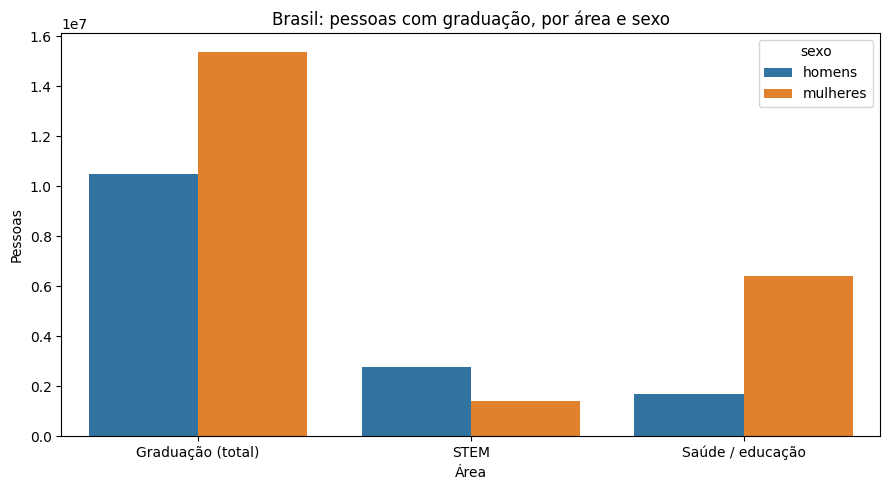

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Os três recortes já preparados nas tabelas anteriores
formacao_total = tabela_1
formacao_stem = tabela_2
formacao_saude = tabela_3

brasil_base = dados.loc[dados["Região/UF"] == "Brasil"].iloc[0]

brasil = pd.DataFrame(
    {
        "area": ["Graduação (total)", "STEM", "Saúde / educação"],
        "homens": [
            brasil_base["Homens"],
            brasil_base["Homens.1"],
            brasil_base["Homens.2"],
        ],
        "mulheres": [
            brasil_base["Mulheres"],
            brasil_base["Mulheres.1"],
            brasil_base["Mulheres.2"],
        ],
    }
)

brasil_long = brasil.melt(
    id_vars="area",
    value_vars=["homens", "mulheres"],
    var_name="sexo",
    value_name="pessoas",
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=brasil_long, x="area", y="pessoas", hue="sexo", ax=ax)
ax.set_title("Brasil: pessoas com graduação, por área e sexo")
ax.set_xlabel("Área")
ax.set_ylabel("Pessoas")
plt.tight_layout()
plt.show()
